In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
class Lattice:
    def __init__(self, a1, a2):
        self.a1 = a1
        self.a2 = a2
        self.a3 = a2-a1
    def getReciprocal(self):
        area = np.linalg.norm(np.cross(np.append(self.a1, 0), np.append(self.a2, 0)))
        b1 = 2 * np.pi * np.array([self.a2[1], -self.a2[0]]) / area
        b2 = 2 * np.pi * np.array([-self.a1[1], self.a1[0]]) / area
        return b1, b2

In [23]:
class Hamiltonian:
    def __init__(self, lattice):
        self.lattice = lattice
    def getHamiltonian(self, kx, ky,t=1):
        b1, b2 = self.lattice.getReciprocal()
        k_dot_a1 = kx * self.lattice.a1[0] + ky * self.lattice.a1[1]
        k_dot_a2 = kx * self.lattice.a2[0] + ky * self.lattice.a2[1]
        k_dot_a3 = kx * self.lattice.a3[0] + ky * self.lattice.a3[1]

        f_k1 = -t * (1 + np.exp(1j * k_dot_a1))
        f_k2 = -t * (1 + np.exp(1j * k_dot_a2))
        f_k3 = -t * (1 + np.exp(1j * k_dot_a3))
        g_k1 = -0.1*t *( (np.exp(1j * k_dot_a3))+(np.exp(-1j * k_dot_a2)))
        g_k2 = -0.1*t * ((np.exp(-1j * k_dot_a1))+(np.exp(-1j * k_dot_a3)))
        g_k3 = -0.1*t * ((np.exp(1j * k_dot_a1))+(np.exp(-1j * k_dot_a2)))


        H = np.array([
            [0, f_k1+g_k1,f_k2+g_k2],
            [np.conj(f_k1)+np.conj(g_k1), 0,f_k3+g_k3],
            [np.conj(f_k2)+np.conj(g_k2),np.conj(f_k3)+np.conj(g_k3),0]
        ], dtype=complex)
        
        return H
    
    def solveHamiltonian(self, kx, ky):
        H = self.getHamiltonian(kx, ky)
        eigenvalues, eigenvectors = np.linalg.eigh(H)
        return eigenvalues

In [24]:
def K_path(numpoints,lattice):
    k_path=[]
    b1,b2 = lattice.getReciprocal()
    K_point = (2*b1 + b2) / 3
    M_point = b1 / 2
    Gamma_point = np.array([0, 0])
    for x,y in zip(np.linspace(0,K_point[0],numpoints),np.linspace(0,K_point[1],numpoints)):
        k_path.append((x,y))
    for x,y in zip(np.linspace(K_point[0],M_point[0],numpoints),np.linspace(K_point[1],M_point[1],numpoints)):
        k_path.append((x,y))
    for x,y in zip(np.linspace(M_point[0],Gamma_point[0],numpoints),np.linspace(M_point[1],Gamma_point[1],numpoints)):
        k_path.append((x,y))
    return k_path


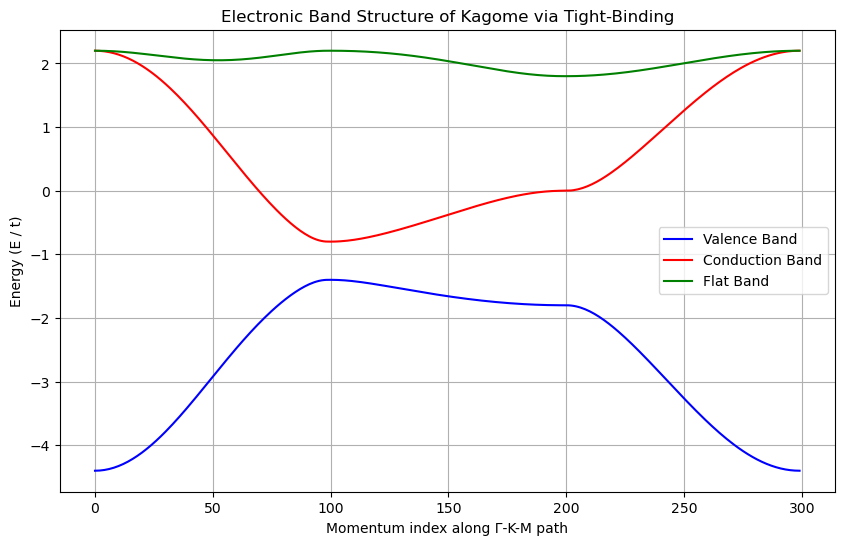

In [25]:
a=1
lattice1=Lattice(np.array([2*a, 0]), np.array([a, 2*a*np.sqrt(3)/2]))
H=Hamiltonian(lattice1)
k_path=[]
k_path=K_path(100,lattice1)
eigenvalues = []
for kx, ky in k_path:
    eigenvalues.append(H.solveHamiltonian(kx, ky))
eigenvalues = np.array(eigenvalues)
plt.figure(figsize=(10, 6))
plt.plot(eigenvalues[:, 0], 'b-', label='Valence Band') 
plt.plot(eigenvalues[:, 1], 'r-', label='Conduction Band') 
plt.plot(eigenvalues[:, 2], 'g-', label='Flat Band') 
plt.title("Electronic Band Structure of Kagome via Tight-Binding")
plt.ylabel("Energy (E / t)")
plt.xlabel("Momentum index along Γ-K-M path")
plt.legend()
plt.grid(True)
plt.show()